<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 104 · What Is Machine Learning?</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">What Is Machine Learning?</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">The three paradigms made concrete on one customer table: a supervised classifier and a regressor, unsupervised segments from K-means, a reinforcement-learning agent that learns from reward, and the statistics-versus-ML mindset, all library-first and explained.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# What Is Machine Learning? The three paradigms, in code
This notebook makes the taxonomy concrete. Using one real customer table we run a **supervised** model (predict a label), a **regression** (predict a number), an **unsupervised** model (find segments with no label), and a tiny **reinforcement-learning** agent (learn from reward), then contrast the **statistics** mindset (explain) with the **machine-learning** mindset (predict). Library-first with `scikit-learn`, `statsmodels`, and `seaborn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, r2_score
import statsmodels.api as sm
pd.set_option('display.max_columns', 30)

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 &#183; THE SHAPE OF ML DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Features and a label</div>
<div style="color:#4a5578;margin-top:6px">Almost every ML problem starts as a table like this.</div>
</div>

In [3]:
try: df = pd.read_excel('../../data/what-is-machine-learning--customers.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'what-is-machine-learning--customers.xlsx', sheet_name='Data')
print('shape:', df.shape)
df.head()

shape: (600, 8)


,customer_id,age,income_k,tenure_months,num_products,monthly_spend,support_calls,churned
0,C7000,43,102,70,4,75.22,1,0
1,C7001,53,86,34,1,48.97,1,0
2,C7002,24,38,6,1,30.25,3,0
3,C7003,30,30,23,1,29.26,4,0
4,C7004,19,44,8,1,51.81,3,0


**What this shows.** Each **row** is one customer; each **column** is a measurement. In ML vocabulary the input columns (age, income, tenure, and so on) are the **features** and the column we might want to predict, `churned` (1 = left, 0 = stayed), is the **label** or **target**. That single distinction, features versus label, splits machine learning into its main branches: if a label is present we can do **supervised** learning; if not, **unsupervised**.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; SUPERVISED LEARNING (CLASSIFICATION)</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Predict a category: will this customer churn?</div>
<div style="color:#4a5578;margin-top:6px">Split the data, train on one part, test on the part the model never saw.</div>
</div>

trained on 450 customers, tested on 150 unseen ones
test accuracy = 77.3%


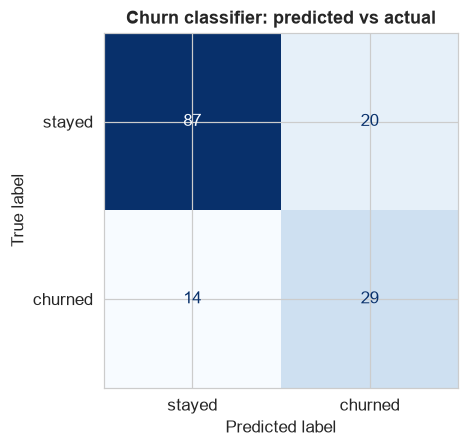

In [4]:
feat = ['age','income_k','tenure_months','num_products','monthly_spend','support_calls']
X, y = df[feat], df['churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
pred = clf.predict(X_test)
print(f'trained on {len(X_train)} customers, tested on {len(X_test)} unseen ones')
print(f'test accuracy = {accuracy_score(y_test, pred):.1%}')
fig, ax = plt.subplots(figsize=(4.8,4.2))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=['stayed','churned']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Churn classifier: predicted vs actual'); plt.tight_layout(); plt.show()

**What the code does.** `train_test_split` holds out 25% of customers as a test set, so we can measure performance on data the model **never saw during training** (the golden rule of ML). `make_pipeline(StandardScaler(), LogisticRegression())` chains two steps: standardize the features, then fit a classifier. We `fit` on the training set and `predict` on the test set.

**Reading the output.** The model learned a mapping from features to the churn label and is right about **three-quarters of the time** on unseen customers. The **confusion matrix** breaks that down: the diagonal cells are correct predictions (stayed-called-stayed, churned-called-churned), the off-diagonal cells are the two kinds of mistake. This is supervised **classification**: the target is a category.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; SUPERVISED LEARNING (REGRESSION)</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Predict a number: the monthly bill</div>
<div style="color:#4a5578;margin-top:6px">Same recipe, but the target is continuous.</div>
</div>

test R2 = 0.825


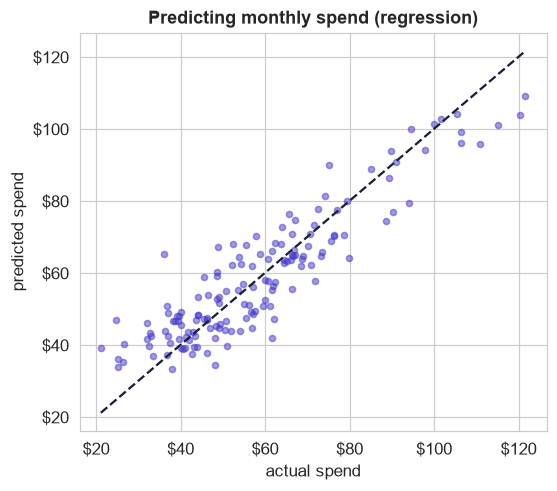

In [5]:
Xr = df[['age','income_k','num_products','tenure_months']]; yr = df['monthly_spend']
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=0)
reg = LinearRegression().fit(Xr_tr, yr_tr)
print(f'test R2 = {reg.score(Xr_te, yr_te):.3f}')
fig, ax = plt.subplots(figsize=(5.2,4.6))
ax.scatter(yr_te, reg.predict(Xr_te), s=16, color=EM, alpha=0.5)
lims=[yr_te.min(), yr_te.max()]; ax.plot(lims, lims, ls='--', color=INK)
ax.set(title='Predicting monthly spend (regression)', xlabel='actual spend', ylabel='predicted spend')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:.0f}')); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:.0f}'))
plt.tight_layout(); plt.show()

**What changed.** Everything is the same supervised recipe (split, fit, evaluate) except the **target is now a number** (`monthly_spend`) instead of a category. That is the difference between the two kinds of supervised learning: **classification** predicts a class, **regression** predicts a quantity. The points hug the diagonal and the test **R-squared** says the model explains most of the variation in the bill, exactly the regression idea from Part XV, now framed as an ML task.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 4 &#183; UNSUPERVISED LEARNING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Find structure with no label</div>
<div style="color:#4a5578;margin-top:6px">K-means groups similar customers into segments, using the features only.</div>
</div>

customers per discovered segment: [269, 89, 242]
         income_k  monthly_spend  num_products
segment                                       
0            39.6           43.5           1.5
1           101.2           89.6           4.5
2            73.3           61.0           2.4


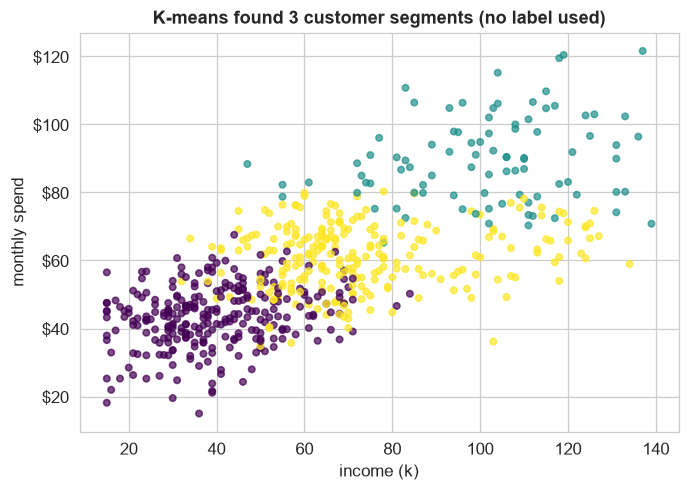

In [6]:
Xu = StandardScaler().fit_transform(df[['income_k','monthly_spend','num_products','tenure_months']])
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xu)
df['segment'] = km.labels_
print('customers per discovered segment:', np.bincount(km.labels_).tolist())
print(df.groupby('segment')[['income_k','monthly_spend','num_products']].mean().round(1))
fig, ax = plt.subplots(figsize=(6.4,4.6))
sc = ax.scatter(df.income_k, df.monthly_spend, c=df.segment, cmap='viridis', s=18, alpha=0.7)
ax.set(title='K-means found 3 customer segments (no label used)', xlabel='income (k)', ylabel='monthly spend')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:.0f}')); plt.tight_layout(); plt.show()

**What the code does.** Notice there is **no `y`** here, only features. `KMeans(n_clusters=3)` looks for three natural groups by putting customers who are close together (after standardizing) into the same cluster. The group means reveal the story: the algorithm recovered a **budget, a standard, and a premium** segment, low-to-high income and spend, entirely from the data's shape. Unsupervised learning does not predict a known answer; it **discovers structure** (segments, topics, anomalies) when no label exists.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; REINFORCEMENT LEARNING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Learn from reward, not from a dataset</div>
<div style="color:#4a5578;margin-top:6px">A tiny agent discovers which of three offers works best by trying them.</div>
</div>

learned value of each offer: [0.027 0.115 0.067]  -> agent settled on offer 2


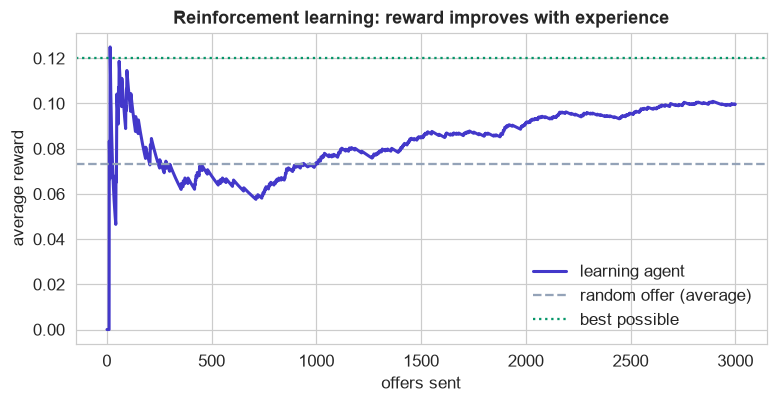

In [7]:
# 3 offers with unknown true response rates; the agent must LEARN which to send, from feedback alone
true_rates = [0.03, 0.12, 0.07]           # hidden from the agent
rng = np.random.default_rng(7)
counts = np.zeros(3); values = np.zeros(3); history = []
for t in range(3000):
    a = rng.integers(3) if rng.random() < 0.1 else int(np.argmax(values))   # explore 10%, else exploit best-so-far
    reward = 1.0 if rng.random() < true_rates[a] else 0.0                    # send offer, observe response
    counts[a] += 1; values[a] += (reward - values[a]) / counts[a]           # update the running estimate
    history.append(reward)
print('learned value of each offer:', values.round(3), ' -> agent settled on offer', int(np.argmax(values))+1)
fig, ax = plt.subplots(figsize=(7.2,3.8))
ax.plot(np.arange(1,len(history)+1), np.cumsum(history)/np.arange(1,len(history)+1), color=EM, lw=2, label='learning agent')
ax.axhline(np.mean(true_rates), color=GREY, ls='--', label='random offer (average)')
ax.axhline(max(true_rates), color=GREEN, ls=':', label='best possible')
ax.set(title='Reinforcement learning: reward improves with experience', xlabel='offers sent', ylabel='average reward'); ax.legend()
plt.tight_layout(); plt.show()

**What this shows.** There is no training table here at all. The agent **acts** (sends one of three offers), receives a **reward** (did the customer respond?), and updates its estimate of each offer's value, mostly picking the best one so far but occasionally exploring. Over a few thousand tries its average reward climbs from the random baseline toward the best-possible rate, and it correctly identifies **offer 2** as the winner. That is **reinforcement learning**: learning a policy from trial and reward, the family behind game-playing and robotics agents.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 6 &#183; STATISTICS vs MACHINE LEARNING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two mindsets on the same data</div>
<div style="color:#4a5578;margin-top:6px">Explain (inference) versus predict (generalization).</div>
</div>

In [8]:
# STATISTICS mindset: WHY do customers churn? fit for interpretation, read coefficients + p-values
Xc = sm.add_constant(StandardScaler().fit_transform(df[feat]))
logit = sm.Logit(df['churned'], Xc).fit(disp=0)
stat = pd.DataFrame({'coef': logit.params.values.round(3), 'p_value': logit.pvalues.values.round(3)}, index=['const']+feat)
print('STATISTICS (inference):'); print(stat.to_string()); print()
# MACHINE-LEARNING mindset: how well will it PREDICT unseen customers? cross-validate
cv = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X, y, cv=5)
print(f'MACHINE LEARNING (prediction): 5-fold accuracy = {cv.mean():.1%} (+/- {cv.std():.1%})')

STATISTICS (inference):
                coef  p_value
const         -1.416    0.000
age            0.020    0.890
income_k      -0.789    0.000
tenure_months -1.180    0.000
num_products   0.160    0.471
monthly_spend  0.403    0.117
support_calls  0.468    0.000

MACHINE LEARNING (prediction): 5-fold accuracy = 79.3% (+/- 4.3%)


**The contrast.** Both use the same logistic model, but ask different questions. **Statistics** asks *which factors drive churn, and are they significant?*, so it reports **coefficients and p-values** (short tenure and frequent support calls raise churn, with tiny p-values). **Machine learning** asks *how accurately will this predict customers I have not seen?*, so it reports a **cross-validated accuracy**. Explanation versus generalization: the same math, two goals, and good practice borrows from both.

## The taxonomy, in one view

- **Supervised** learning has a labeled target: **classification** predicts a category (churn yes/no), **regression** predicts a number (the monthly bill). It is by far the most common industry setting.
- **Unsupervised** learning has no label: it finds structure, clusters (customer segments), dimensionality reduction, anomaly detection.
- **Reinforcement** learning has no dataset at all: an agent learns a policy from **reward** by interacting with an environment.
- **Statistics vs ML** is a difference of emphasis, not tools: statistics leans on **inference** (explain, with uncertainty), ML leans on **prediction** (generalize to new data, measured by held-out performance).

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>